# Notebook 08: Component VaR Analysis

This notebook implements portfolio risk decomposition:

1. **Marginal VaR** - Sensitivity of VaR to position changes
2. **Component VaR** - Each asset's contribution to total VaR
3. **Incremental VaR** - Impact of adding/removing positions
4. **Risk Budgeting** - Risk-weighted analysis

---

In [1]:
import numpy as np
import pandas as pd
import json
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported!")

Libraries imported!


In [2]:
# Load data
with open('../portfolio_config.json', 'r') as f:
    config = json.load(f)

TICKERS = config['portfolio']['tickers']
NAMES = config['portfolio']['names']
WEIGHTS = np.array(config['portfolio']['weights'])
CONFIDENCE = config['var_params']['confidence_var']

asset_returns = pd.read_csv('../outputs/asset_returns.csv', index_col=0, parse_dates=True)
train_returns = asset_returns[config['dates']['train_start']:config['dates']['train_end']]

print(f"Assets: {TICKERS}")
print(f"Weights: {WEIGHTS}")

Assets: ['AAPL', 'MSFT', 'NVDA', 'GOOG', 'AMD']
Weights: [0.3  0.25 0.2  0.15 0.1 ]


## 8.1 Portfolio Risk Metrics

In [3]:
# ==============================================================================
# Portfolio Risk Calculation
# ==============================================================================

# Step 1: Calculate the covariance matrix Σ of asset returns
# Each element Σ[i,j] = Cov(Ri, Rj) represents co-movement between assets
# Diagonal elements Σ[i,i] = Var(Ri) are individual asset variances
cov_matrix = train_returns.cov()

# Step 2: Calculate portfolio variance using matrix multiplication
# Portfolio Variance = w' × Σ × w
# where w is the weight vector and Σ is the covariance matrix
# The @ operator performs matrix multiplication in NumPy
port_variance = WEIGHTS @ cov_matrix @ WEIGHTS

# Step 3: Portfolio volatility (standard deviation) = √(variance)
port_volatility = np.sqrt(port_variance)

# Step 4: Calculate Portfolio VaR using parametric approach
# VaR = z_α × σ_portfolio
# where z_α = norm.ppf(1 - 0.99) = -2.326 for 99% confidence
z_score = norm.ppf(1 - CONFIDENCE)  # Left-tail z-score (negative)
port_var = z_score * port_volatility  # VaR is negative (representing loss)

print(f"Portfolio Volatility: {port_volatility:.4%}")
print(f"Portfolio 99% VaR: {abs(port_var):.4%}")

Portfolio Volatility: 1.9242%
Portfolio 99% VaR: 4.4764%


## 8.2 Marginal VaR

Marginal VaR measures the sensitivity of portfolio VaR to small changes in position weights:

$$MVaR_i = \frac{\partial VaR}{\partial w_i} = z_\alpha \times \frac{Cov(R_i, R_p)}{\sigma_p}$$

In [4]:
def calculate_marginal_var(weights, cov_matrix, confidence=0.99):
    """
    Calculate Marginal VaR for each asset.
    
    Marginal VaR measures the sensitivity of portfolio VaR to small changes
    in position weights. It answers: "How much does VaR change per unit
    increase in asset weight?"
    
    Formula: MVaR_i = ∂VaR/∂w_i = z_α × Cov(R_i, R_p) / σ_p
    """
    # Step 1: Calculate portfolio variance = w' × Σ × w
    port_var = weights @ cov_matrix @ weights
    
    # Step 2: Portfolio volatility = √(variance)
    port_vol = np.sqrt(port_var)
    
    # Step 3: Get z-score for the confidence level
    # For 99% confidence: z = -2.326
    z_score = norm.ppf(1 - confidence)
    
    # Step 4: Calculate Marginal VaR using the formula:
    # MVaR = z × (Σ × w) / σ_p
    #
    # The term (Σ × w) gives Cov(R_i, R_p) for each asset i
    # because Cov(R_i, R_p) = Cov(R_i, Σ w_j × R_j) = Σ_j w_j × Cov(R_i, R_j)
    # which equals the i-th element of (Σ × w)
    marginal_var = z_score * (cov_matrix @ weights) / port_vol
    
    return marginal_var

# Calculate Marginal VaR for each asset in the portfolio
marginal_var = calculate_marginal_var(WEIGHTS, cov_matrix.values, CONFIDENCE)

# Create summary DataFrame
marginal_df = pd.DataFrame({
    'Asset': TICKERS,
    'Weight': WEIGHTS,
    'Marginal VaR': marginal_var,
    'Marginal VaR (%)': [f"{abs(m):.2%}" for m in marginal_var]
})

display(Markdown("### Marginal VaR by Asset"))
display(marginal_df)

### Marginal VaR by Asset

,Asset,Weight,Marginal VaR,Marginal VaR (%)
0,AAPL,0.30,-0.032931,3.29%
1,MSFT,0.25,-0.035009,3.50%
2,NVDA,0.20,-0.070977,7.10%
3,GOOG,0.15,-0.037696,3.77%
4,AMD,0.10,-0.062826,6.28%


## 8.3 Component VaR

Component VaR shows each asset's contribution to total portfolio VaR:

$$CVaR_i = w_i \times MVaR_i$$

**Key Property**: Sum of Component VaRs = Portfolio VaR

In [5]:
def calculate_component_var(weights, marginal_var):
    """
    Calculate Component VaR for each asset.
    
    Component VaR decomposes total portfolio VaR into contributions from
    each individual asset. It answers: "How much of the total VaR comes
    from each position?"
    
    Formula: CVaR_i = w_i × MVaR_i
    
    Key Property (Euler's Theorem): 
        Sum of all Component VaRs = Portfolio VaR
        Σ CVaR_i = VaR_portfolio
    
    This additivity property makes Component VaR useful for risk budgeting.
    """
    # Component VaR = Weight × Marginal VaR
    # This represents each asset's "fair share" of portfolio risk
    return weights * marginal_var

# Calculate Component VaR for each asset
component_var = calculate_component_var(WEIGHTS, marginal_var)

# Create summary DataFrame showing Component VaR and percentage contribution
component_df = pd.DataFrame({
    'Asset': TICKERS,
    'Weight': WEIGHTS,
    'Component VaR': component_var,
    # Risk contribution = CVaR_i / Σ CVaR_i (percentage of total risk)
    'Contribution (%)': component_var / component_var.sum() * 100
})

display(Markdown("### Component VaR by Asset"))
display(component_df.style.format({
    'Weight': '{:.2%}',
    'Component VaR': '{:.4%}',
    'Contribution (%)': '{:.1f}%'
}))

# Verify the key property: Sum of Component VaRs = Portfolio VaR
# This equality confirms correct implementation of the Euler decomposition
print(f"\nSum of Component VaRs: {abs(component_var.sum()):.4%}")
print(f"Portfolio VaR: {abs(port_var):.4%}")
print(f"Difference: {abs(component_var.sum() - port_var):.6%} (should be ~0)")

### Component VaR by Asset

,Asset,Weight,Component VaR,Contribution (%)
0,AAPL,30.00%,-0.9879%,22.1%
1,MSFT,25.00%,-0.8752%,19.6%
2,NVDA,20.00%,-1.4195%,31.7%
3,GOOG,15.00%,-0.5654%,12.6%
4,AMD,10.00%,-0.6283%,14.0%



Sum of Component VaRs: 4.4764%
Portfolio VaR: 4.4764%
Difference: 0.000000% (should be ~0)


## 8.4 Visualization

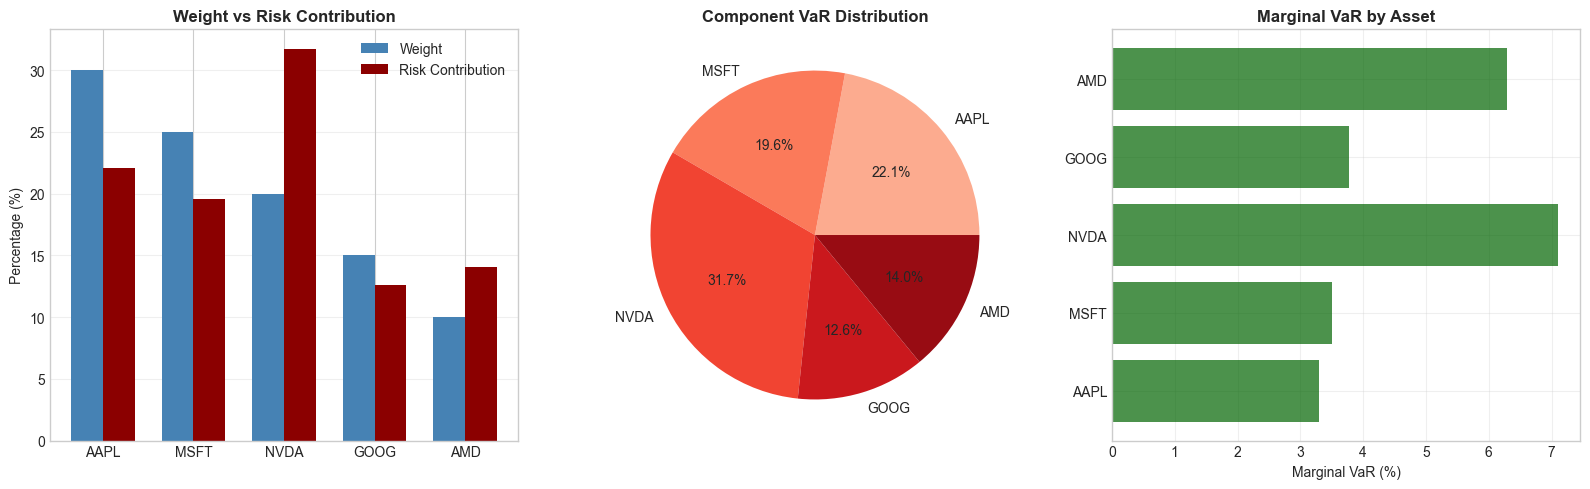

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: Weight vs Risk Contribution
ax1 = axes[0]
x = np.arange(len(TICKERS))
width = 0.35

bars1 = ax1.bar(x - width/2, WEIGHTS*100, width, label='Weight', color='steelblue')
bars2 = ax1.bar(x + width/2, abs(component_var)/abs(component_var).sum()*100, width, 
                label='Risk Contribution', color='darkred')

ax1.set_ylabel('Percentage (%)')
ax1.set_title('Weight vs Risk Contribution', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(TICKERS)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Middle: Component VaR pie chart
ax2 = axes[1]
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(TICKERS)))
ax2.pie(abs(component_var), labels=TICKERS, autopct='%1.1f%%', colors=colors)
ax2.set_title('Component VaR Distribution', fontweight='bold')

# Right: Marginal VaR
ax3 = axes[2]
ax3.barh(TICKERS, abs(marginal_var)*100, color='darkgreen', alpha=0.7)
ax3.set_xlabel('Marginal VaR (%)')
ax3.set_title('Marginal VaR by Asset', fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/08_component_var.png', dpi=300, bbox_inches='tight')
plt.show()

## 8.5 Risk/Weight Ratio Analysis

In [7]:
# ==============================================================================
# Risk/Weight Ratio Analysis
# ==============================================================================
# This analysis identifies assets that contribute disproportionate risk
# relative to their portfolio weight.

# Step 1: Calculate risk contribution as a percentage of total risk
# Risk Contribution_i = |CVaR_i| / Σ|CVaR_j|
risk_contribution = abs(component_var) / abs(component_var).sum()

# Step 2: Calculate Risk/Weight Ratio
# Ratio = Risk Contribution / Weight
# 
# Interpretation:
#   - Ratio > 1: Asset contributes MORE risk than its weight suggests
#                (may indicate concentration risk or high correlation)
#   - Ratio < 1: Asset contributes LESS risk than weight (diversification benefit)
#   - Ratio = 1: Risk contribution is proportional to weight (neutral)
risk_weight_ratio = risk_contribution / WEIGHTS

# Create summary DataFrame
ratio_df = pd.DataFrame({
    'Asset': TICKERS,
    'Weight (%)': WEIGHTS * 100,
    'Risk Contribution (%)': risk_contribution * 100,
    'Risk/Weight Ratio': risk_weight_ratio
})

# Classify each asset based on its Risk/Weight Ratio
# Using thresholds: >1.1 = Overweight Risk, <0.9 = Underweight Risk
ratio_df['Assessment'] = ratio_df['Risk/Weight Ratio'].apply(
    lambda x: 'Overweight Risk' if x > 1.1 else ('Underweight Risk' if x < 0.9 else 'Balanced')
)

display(Markdown("### Risk/Weight Ratio Analysis"))
display(ratio_df.style.format({
    'Weight (%)': '{:.1f}%',
    'Risk Contribution (%)': '{:.1f}%',
    'Risk/Weight Ratio': '{:.2f}'
}))

display(Markdown("""
**Interpretation:**
- Ratio > 1: Asset contributes MORE risk than its weight suggests
- Ratio < 1: Asset contributes LESS risk (diversification benefit)
- Ratio = 1: Risk contribution proportional to weight
"""))

### Risk/Weight Ratio Analysis

,Asset,Weight (%),Risk Contribution (%),Risk/Weight Ratio,Assessment
0,AAPL,30.0%,22.1%,0.74,Underweight Risk
1,MSFT,25.0%,19.6%,0.78,Underweight Risk
2,NVDA,20.0%,31.7%,1.59,Overweight Risk
3,GOOG,15.0%,12.6%,0.84,Underweight Risk
4,AMD,10.0%,14.0%,1.40,Overweight Risk



**Interpretation:**
- Ratio > 1: Asset contributes MORE risk than its weight suggests
- Ratio < 1: Asset contributes LESS risk (diversification benefit)
- Ratio = 1: Risk contribution proportional to weight


In [8]:
# Save results
component_results = {
    'portfolio_var': float(abs(port_var)),
    'portfolio_vol': float(port_volatility),
    'marginal_var': dict(zip(TICKERS, marginal_var.tolist())),
    'component_var': dict(zip(TICKERS, component_var.tolist())),
    'risk_contribution': dict(zip(TICKERS, risk_contribution.tolist()))
}

with open('../outputs/component_var_results.json', 'w') as f:
    json.dump(component_results, f, indent=4)

print("Component VaR results saved!")

Component VaR results saved!


---
## Summary

**Key Findings:**
- Marginal VaR shows sensitivity of portfolio risk to each position
- Component VaR decomposes total VaR into asset-level contributions
- Risk/Weight ratio identifies over/underweight risk exposures

This analysis enables:
- Risk budgeting decisions
- Hedging prioritization
- Portfolio optimization